<a href="https://colab.research.google.com/github/kxrrym03/US-Top-50-Universities/blob/main/US_Top_50_Universities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving US_Top_50_Universities_2026.csv to US_Top_50_Universities_2026.csv


In [4]:
df = pd.read_csv('US_Top_50_Universities_2026.csv')
df.shape

(50, 8)

In [5]:
df.head()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
0,Massachusetts Institute of Technology (MIT),1,1861,Private,MA,100.0,91.6,96.2
1,Columbia University,2,1754,Private,NY,95.9,83.7,92.1
2,Princeton University,3,1746,Private,NJ,99.0,70.0,94.5
3,Stanford University,4,1891,Private,CA,99.5,73.5,97.8
4,"University of California, Berkeley",5,1868,Public,CA,98.9,70.6,91.4


In [6]:
df.tail()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
45,University of Texas at Austin,46,1883,Public,TX,90.1,46.2,89.2
46,Washington and Lee University,47,1749,Private,VA,28.5,4.2,91.5
47,Colgate University,48,1819,Private,NY,30.2,8.4,88.1
48,New York University (NYU),49,1831,Private,NY,94.3,74.1,87.4
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3


In [7]:
df.isnull().sum()

,0
University_Name,0
National_Rank,0
Founded_Year,0
Institution_Type,0
State,0
Research_Impact_Score,0
Intl_Student_Ratio,0
Employment_Rate,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,National_Rank,Founded_Year,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
count,50.00000,50.00000,50.000000,50.000000,50.000000
mean,25.50000,1844.04000,80.662000,44.630000,89.424000
std,14.57738,64.89142,23.380856,31.729985,3.825562
min,1.00000,1636.00000,28.500000,4.200000,81.900000
25%,13.25000,1817.50000,82.100000,14.900000,86.900000
50%,25.50000,1858.50000,89.650000,35.800000,89.300000
75%,37.75000,1884.50000,96.250000,73.950000,92.325000
max,50.00000,1965.00000,100.000000,94.200000,97.800000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   University_Name        50 non-null     object 
 1   National_Rank          50 non-null     int64  
 2   Founded_Year           50 non-null     int64  
 3   Institution_Type       50 non-null     object 
 4   State                  50 non-null     object 
 5   Research_Impact_Score  50 non-null     float64
 6   Intl_Student_Ratio     50 non-null     float64
 7   Employment_Rate        50 non-null     float64
dtypes: float64(3), int64(2), object(3)
memory usage: 3.3+ KB


In [11]:
df.columns

Index(['University_Name', 'National_Rank', 'Founded_Year', 'Institution_Type',
       'State', 'Research_Impact_Score', 'Intl_Student_Ratio',
       'Employment_Rate'],
      dtype='object')

In [12]:
df.dtypes

,0
University_Name,object
National_Rank,int64
Founded_Year,int64
Institution_Type,object
State,object
Research_Impact_Score,float64
Intl_Student_Ratio,float64
Employment_Rate,float64


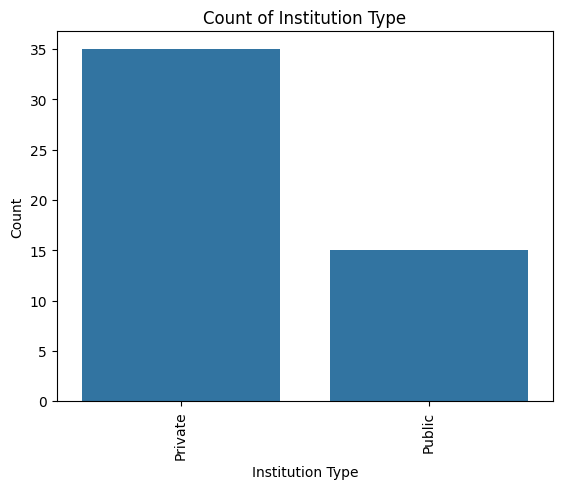

In [13]:
sns.countplot(data=df, x='Institution_Type')
plt.title('Count of Institution Type')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.xlabel('Institution Type')
plt.show()

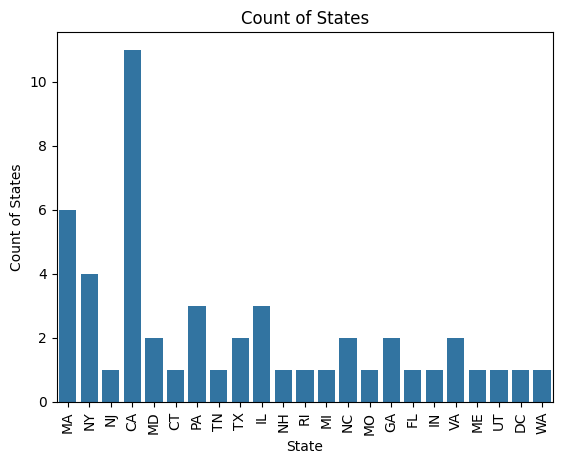

In [14]:
sns.countplot(data=df, x='State')
plt.title('Count of States')
plt.xticks(rotation=90)
plt.ylabel('Count of States')
plt.xlabel('State')
plt.show()

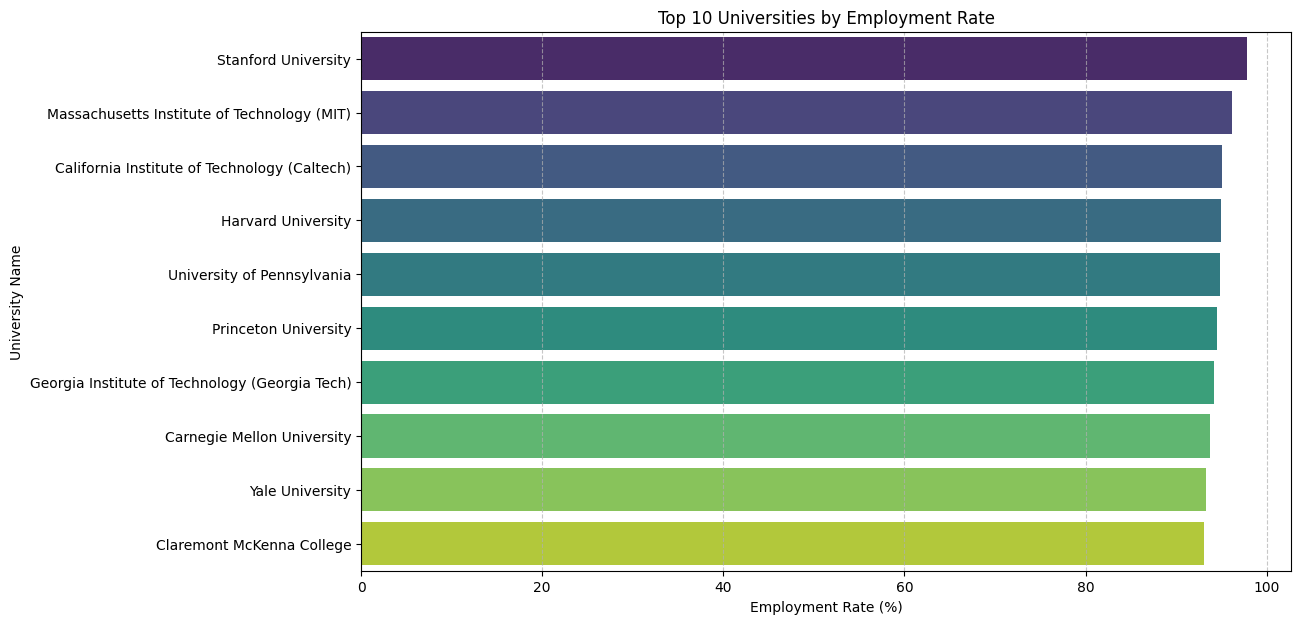

In [15]:
top_10_employment = df.nlargest(10, 'Employment_Rate')

plt.figure(figsize=(12, 7))
sns.barplot(x='Employment_Rate', y='University_Name', data=top_10_employment, palette='viridis')
plt.title('Top 10 Universities by Employment Rate')
plt.xlabel('Employment Rate (%)')
plt.ylabel('University Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

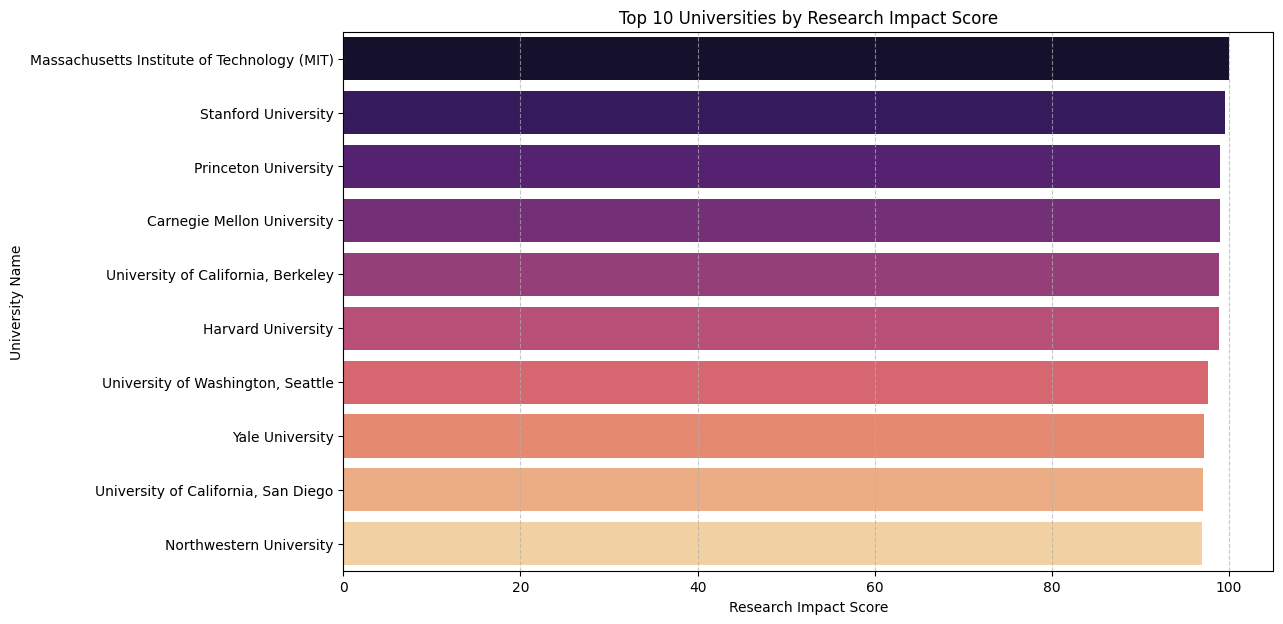

In [16]:
top_10_research_impact = df.nlargest(10, 'Research_Impact_Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Research_Impact_Score', y='University_Name', data=top_10_research_impact, palette='magma')
plt.title('Top 10 Universities by Research Impact Score')
plt.xlabel('Research Impact Score')
plt.ylabel('University Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

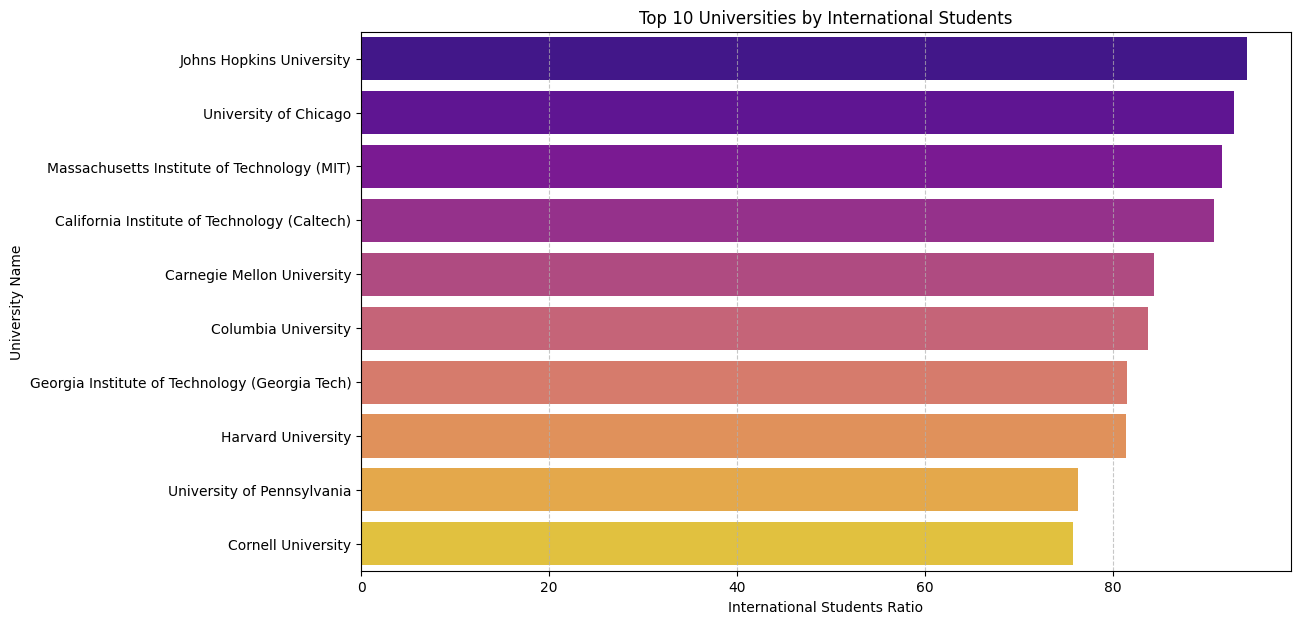

In [18]:
top_10_International_students = df.nlargest(10, 'Intl_Student_Ratio')

plt.figure(figsize=(12, 7))
sns.barplot(x='Intl_Student_Ratio', y='University_Name', data=top_10_International_students, palette='plasma')
plt.title('Top 10 Universities by International Students')
plt.xlabel('International Students Ratio')
plt.ylabel('University Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

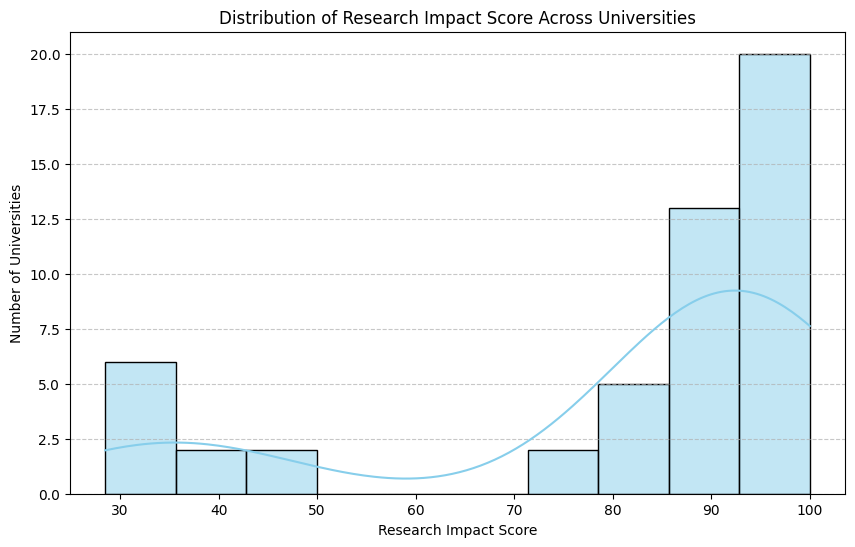

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Research_Impact_Score'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Research Impact Score Across Universities')
plt.xlabel('Research Impact Score')
plt.ylabel('Number of Universities')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
pip install geopy

In [21]:
from geopy.geocoders import Nominatim
import numpy as np

geolocator = Nominatim(user_agent="my_university_geocoders")

latitudes = []
longitudes = []

for university_name in df['University_Name']:
    try:
        location = geolocator.geocode(university_name, timeout=10)
        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            latitudes.append(np.nan)
            longitudes.append(np.nan)
    except Exception as e:
        print(f"Error geocoding {university_name}: {e}")
        latitudes.append(np.nan)
        longitudes.append(np.nan)

coords_df = pd.DataFrame({
    'University_Name': df['University_Name'],
    'Latitude': latitudes,
    'Longitude': longitudes
})

print(coords_df.head())

# Merge the coordinates back to the original DataFrame
df = pd.merge(df, coords_df, on='University_Name', how='left')
print(df.head())

                               University_Name   Latitude   Longitude
0  Massachusetts Institute of Technology (MIT)        NaN         NaN
1                          Columbia University  40.807751  -73.962490
2                         Princeton University  40.338675  -74.658366
3                          Stanford University  37.431314 -122.169365
4           University of California, Berkeley  33.648772 -117.836500
                               University_Name  National_Rank  Founded_Year  \
0  Massachusetts Institute of Technology (MIT)              1          1861   
1                          Columbia University              2          1754   
2                         Princeton University              3          1746   
3                          Stanford University              4          1891   
4           University of California, Berkeley              5          1868   

  Institution_Type State  Research_Impact_Score  Intl_Student_Ratio  \
0          Private    MA          

In [22]:
import folium

# Create a new DataFrame by dropping rows with NaN values in Latitude or Longitude
df_map = df.dropna(subset=['Latitude', 'Longitude']).copy()

if df_map.empty:
    print("No valid university coordinates to plot on the map.")
else:

    map_center = [df_map['Latitude'].mean(), df_map['Longitude'].mean()]
    university_map = folium.Map(location=map_center, zoom_start=4)


    for index, row in df_map.iterrows():
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=row['University_Name']
        ).add_to(university_map)

    # Display the map
    display(university_map)